In [1]:
# Importing Necessay Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# reading the data
data = pd.read_csv('Instagram-Reach.csv')
print(data.head())

                  Date  Instagram reach
0  2022-04-01T00:00:00             7620
1  2022-04-02T00:00:00            12859
2  2022-04-03T00:00:00            16008
3  2022-04-04T00:00:00            24349
4  2022-04-05T00:00:00            20532


In [3]:
data.columns

Index(['Date', 'Instagram reach'], dtype='object')

In [4]:
# extracting only date values from the date cloumn

data["Date"] = pd.to_datetime(data["Date"])


# Extract only the date part from the "Date" column
data["Date"] = data["Date"].dt.date

In [5]:
data.head()

,Date,Instagram reach
0,2022-04-01,7620
1,2022-04-02,12859
2,2022-04-03,16008
3,2022-04-04,24349
4,2022-04-05,20532


In [6]:
# visualizing the trend of the data

fig = go.Figure()
fig.add_trace(go.Scatter(x=data['Date'],
                         y=data['Instagram reach'],
                         mode='lines', name='Instagram reach'))


fig.update_layout(title='Instagram Reach Trend', xaxis_title='Date', yaxis_title='Instagram Reach')


fig.show()

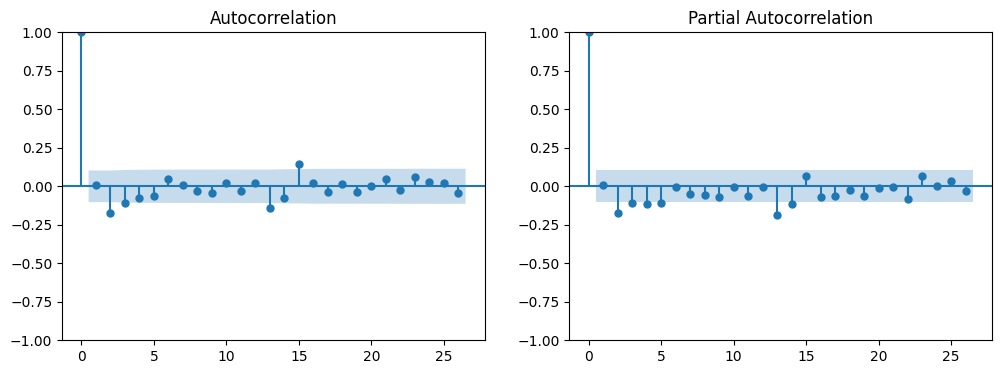

In [7]:
# resetting index
time_series = data.set_index('Date')['Instagram reach']


# Differencing
differenced_series = time_series.diff().dropna()


# Plot ACF and PACF of differenced time series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series, ax=axes[0])
plot_pacf(differenced_series, ax=axes[1])
plt.show()

In [8]:
p, d, q = 1, 1, 1 # d = 1 because the data is non-stationary
model = ARIMA(time_series, order=(p, d, q))
results = model.fit()

print(results.summary())

c:\Users\Dell\anaconda3\envs\ML\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\Dell\anaconda3\envs\ML\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\Dell\anaconda3\envs\ML\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



                               SARIMAX Results                                
Dep. Variable:        Instagram reach   No. Observations:                  365
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4026.336
Date:                Thu, 04 Sep 2025   AIC                           8058.672
Time:                        17:12:57   BIC                           8070.364
Sample:                    04-01-2022   HQIC                          8063.319
                         - 03-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7791      0.046     17.084      0.000       0.690       0.869
ma.L1         -0.9607      0.022    -44.607      0.000      -1.003      -0.918
sigma2      2.559e+08   2.81e-11   9.11e+18      0.0

In [9]:
# Predict future values
future_steps = 100
predictions = results.predict(len(time_series), len(time_series) + future_steps - 1)
print(predictions)

2023-04-01    23434.362334
2023-04-02    24541.004437
2023-04-03    25403.218757
2023-04-04    26074.992886
2023-04-05    26598.389991
                  ...     
2023-07-05    28444.663250
2023-07-06    28444.663250
2023-07-07    28444.663250
2023-07-08    28444.663250
2023-07-09    28444.663250
Freq: D, Name: predicted_mean, Length: 100, dtype: float64


In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
p, d, q, s = 1, 1, 1, 12

model = SARIMAX(time_series, order=(p, d, q), seasonal_order=(p, d, q, s))
results = model.fit()
print(results.summary())

c:\Users\Dell\anaconda3\envs\ML\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

c:\Users\Dell\anaconda3\envs\ML\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



                                     SARIMAX Results                                      
Dep. Variable:                    Instagram reach   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3944.546
Date:                            Thu, 04 Sep 2025   AIC                           7899.092
Time:                                    17:17:16   BIC                           7918.410
Sample:                                04-01-2022   HQIC                          7906.779
                                     - 03-31-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7847      0.086      9.116      0.000       0.616       0.953
ma.L1         -0.9596      0.045   